<h1 align="center">IE406 Machine Learning - Lab 1</h1>
<h2>Name: Anshul Rai</h2>
<h2>ID: 202401016</h2>

In [63]:
import numpy as np
from sklearn.datasets import fetch_california_housing

<h3>TASK #1</h3>
<h4>1. Load the California Housing dataset and save the features and the target labels in numpy matrices.</h4>

In [64]:
data = fetch_california_housing()
X = np.array(data.data)
Y = np.array(data.target)

print(X.shape)
print(Y.shape)

(20640, 8)
(20640,)


<h4>
2. Randomly split the dataset into 3 mutually exclusive sets:
    
• Training Set (60%)

• Validation Set (20%)

• Test Set (20%)

Use a fixed random state so that the same train-validation-test split is obtained every
time the program is executed. You should use NumPy to perform the random shuffling
and splitting with np.random.seed(9432)
</h4>

In [65]:
np.random.seed(9432)

indices = np.random.permutation(len(X))

X = X[indices]
Y = Y[indices]

n = len(X)

train_end = int(0.6*n)
val_end = int(0.8*n)

X_train = X[:train_end]
Y_train = Y[:train_end]

X_val = X[train_end:val_end]
Y_val = Y[train_end:val_end]

X_test = X[val_end:]
Y_test = Y[val_end:]

<h4>
3. Feature Normalization: 
    
Normalize each feature dimension to have a 0 mean and unit standard deviation. Save the normalization parameters (mean and standard deviation of the test set) as these parameters computed from the training set should be used to also normalize the validation and the test set. The mean and standard deviation must be calculated only from the training set. Do not calculate separate normalization parameters for the validation or test sets.
</h4>

In [66]:
# Feature Normalization
train_mean = np.mean(X_train, axis = 0)
train_std = np.std(X_train, axis = 0)

X_train = (X_train - train_mean)/train_std                           # Z = (X - mean) / std, standord normal variable
X_val = (X_val - train_mean)/train_std
X_test = (X_test - train_mean)/train_std

<h4>
4. Feature Augmentation: Add an extra column of 1 to the features to incorporate
Bias as a matrix multiplication.
</h4>

In [67]:
X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_val = np.hstack((np.ones((X_val.shape[0], 1)), X_val))
X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

<h4>
5. Standardize the Ground Truth Target values to also have a 0 mean and unit variance.
Use only the parameters from the training set to standardize the targets
for the validation and test set. Before computation of any performance
metric such as RMSE, MAPE, R-squared etc, the model should use the
unnormalized target values and map the predictions back to the original
range.
</h4>

In [68]:
Y_mean = np.mean(Y_train, axis = 0)
Y_std = np.std(Y_train, axis = 0)

Y_train_original = Y_train.copy()
Y_val_original = Y_val.copy()
Y_test_original = Y_test.copy()

Y_train = (Y_train - Y_mean) / Y_std
Y_val = (Y_val - Y_mean) / Y_std
Y_test = (Y_test - Y_mean) / Y_std

<h3>TASK #2</h3>
<h4>
1. Implement the algorithm completely from scratch using only Python and NumPy. Do not use any pre-built regression model, optimizer, or gradient-descent implementation from ‘sklearn‘ or any other machine learning library.
</h4>

<h4>
2. Implement the Mean Squared Error (MSE) loss function and its gradients with respect to the model weights manually using matrix operations. The model weights should be initialized with a 0 vector.
</h4>

In [69]:
def predict(X, W):
    return X @ W

def mse_loss(X, Y, W):
    predictions = predict(X, W)
    error = predictions - Y
    return np.mean(error ** 2)

def compute_gradient(X, Y, W):
    m = X.shape[0]

    predictions = predict(X, W)
    error = predictions - Y

    gradient = (2/m) * (X.T @ error)

    return gradient

<h4>
3. Use a maximum of 1000 epochs. An epoch is defined as one complete pass through the entire training dataset. Thus, one epoch consists of multiple mini-batch gradient updates. At the beginning of every epoch, randomly shuffle the training data before forming mini-batches.
</h4>

<h4>
4. The learning rate should remain fixed throughout training. Do not use learning-rate decay or scheduling.
</h4>

<h4>
5. At the end of each epoch, compute the MSE on the complete validation set using the current model parameters. The validation set must not be used to update the model parameters.
</h4>

<h4>
6. During each epoch, accumulate the MSE loss computed for each mini-batch. At the end of the epoch, compute the epoch training MSE as the sample-weighted average of the mini-batch losses. This provides an approximation to the true training MSE without requiring an additional pass through the complete training set solely to calculate the training loss. If the final mini-batch contains fewer samples than the other mini-batches, ensure that the epoch training MSE is computed as a sample-weighted average.
</h4>

<h4>
7. Implement Early Stopping with a patience of 100 epochs, based on the validation MSE. Save the model parameters whenever a new lowest validation MSE is obtained. If the validation MSE does not improve for 100 consecutive epochs, terminate training. Once training is complete, return the model parameters corresponding to the lowest validation MSE observed during training. Also return the epoch number at which the lowest validation loss was observed.
</h4>

<h4>
8. The training function should allow the learning rate and batch size to be specified as user inputs. It should return:
    
– the optimized model weights and bias corresponding to the best validation performance,

– the running average of the training MSE curve and the validation loss MSE curve for all epochs completed before early stopping or reaching the maximum number of epochs.
</h4>

In [70]:
def train_model(X_train, Y_train, X_val, Y_val, learning_rate, batch_size):
    W = np.zeros(X_train.shape[1])

    max_epochs = 1000
    best_epoch = 0
    best_val_mse = np.inf
    best_W = None
    patience_cnt = 0
    patience = 100

    # for storing losses after each epoch
    train_losses = []
    val_losses = []

    for epoch in range(max_epochs):
        indices = np.random.permutation(len(X_train))
        X_shuffled = X_train[indices]
        Y_shuffled = Y_train[indices]

        epoch_loss = 0
        num_samples = 0

        for start in range(0, len(X_train), batch_size):
            end = start + batch_size

            X_batch = X_shuffled[start:end]
            Y_batch = Y_shuffled[start:end]

            # computing gradient
            gradient = compute_gradient(X_batch, Y_batch, W)

            # updating weights
            W = W - learning_rate*gradient

            # batch mse
            batch_mse = mse_loss(X_batch, Y_batch, W)

            batch_size_actual = len(X_batch)             # for the case of last mini-batch because it may be less than batch_size

            epoch_loss += batch_mse * batch_size_actual       # because we will take weighted mean of the training mse later so multiplying with the batch size
            num_samples += batch_size_actual

        train_mse = epoch_loss / num_samples
        
        val_mse = mse_loss(X_val, Y_val, W)

        train_losses.append(train_mse)
        val_losses.append(val_mse)

        if val_mse < best_val_mse:
            best_epoch = epoch + 1
            best_val_mse = val_mse
            best_W = W.copy()                               # copy because if we just write W, best_W will also point to the same W and further when we will update W, best_W will also be changed, which is not desired.
            patience_cnt = 0

        else:
            patience_cnt += 1
            
        if patience_cnt == patience:
            break

    return best_W, best_epoch, best_val_mse, train_losses, val_losses

<h3>Task #3</h3>

<h4>
Train the model using the following learning rates:
    
- 10−5
- 10−4
- 10−3
- 10−2
- 10−1
- 1, 10
  
Use a batch size of 128.

Plot:
For each of the seven learning rates, generate a separate plot showing both the training
MSE and validation MSE curves on the same plot. Thus, generate a total of seven plots,
one for each learning rate.

For each plot:

• X-axis: Epoch

• Y-axis: MSE Loss

• Plot the training MSE and validation MSE using two different colors.

• Include a legend identifying the Training and Validation curves.

• Clearly indicate the learning rate in the plot title.

• Use appropriate axis labels.

Determine the learning rate that gives the best validation performance.
</h4>

In [71]:
learning_rates = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]

results_lr = {}    # dictionary for storing the results for each learning rate

for lr in learning_rates:
    best_W, best_epoch, best_val_mse, train_losses, val_losses = train_model(X_train, Y_train, X_val, Y_val, learning_rate = lr, batch_size = 128)

    results_lr[lr] = {
        "W": best_W,
        "best_epoch": best_epoch,
        "train_losses": train_losses,
        "val_losses": val_losses
    }

# print(results_lr)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27304\3693895233.py:7: RuntimeWarning: overflow encountered in square
  return np.mean(error ** 2)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27304\3693895233.py:2: RuntimeWarning: overflow encountered in matmul
  return X @ W
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27304\3693895233.py:15: RuntimeWarning: overflow encountered in matmul
  gradient = (2/m) * (X.T @ error)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27304\3693895233.py:2: RuntimeWarning: invalid value encountered in matmul
  return X @ W
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27304\3693895233.py:15: RuntimeWarning: invalid value encountered in matmul
  gradient = (2/m) * (X.T @ error)


In [72]:
for lr in learning_rates:
    print(lr, len(results_lr[lr]["train_losses"]), len(results_lr[lr]["val_losses"]))

1e-05 1000 1000
0.0001 1000 1000
0.001 407 407
0.01 126 126
0.1 101 101
1 101 101
10 100 100


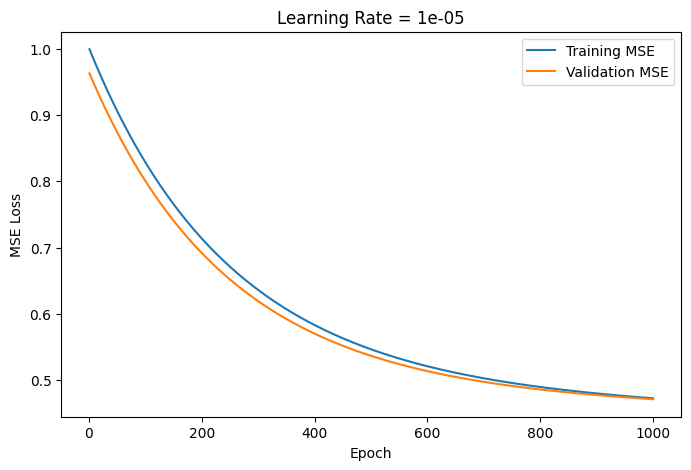

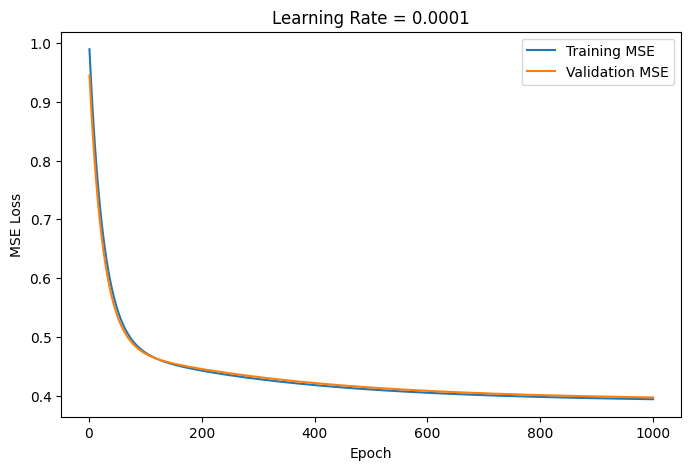

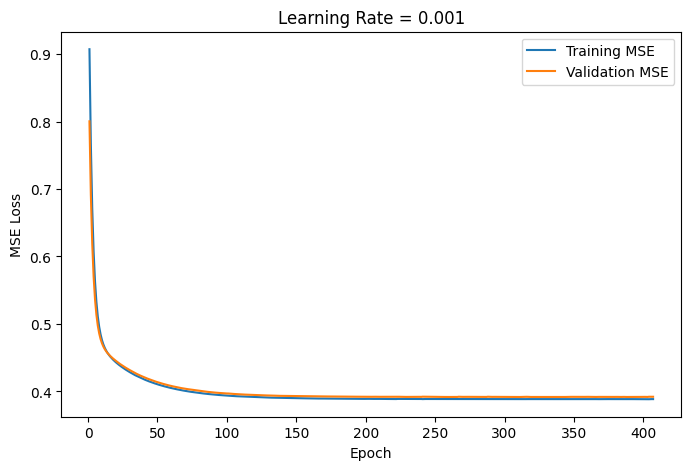

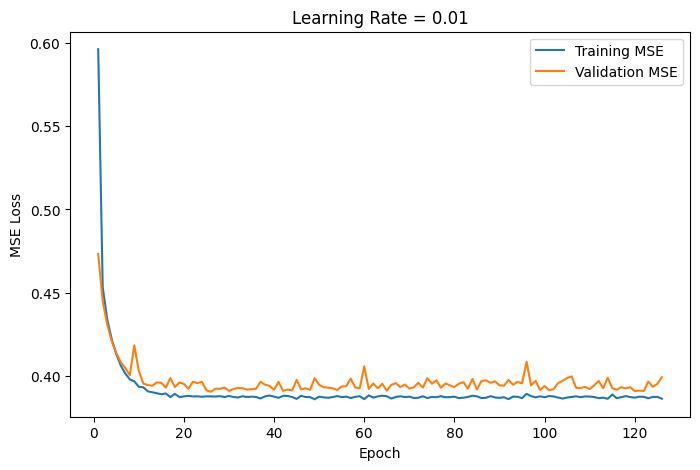

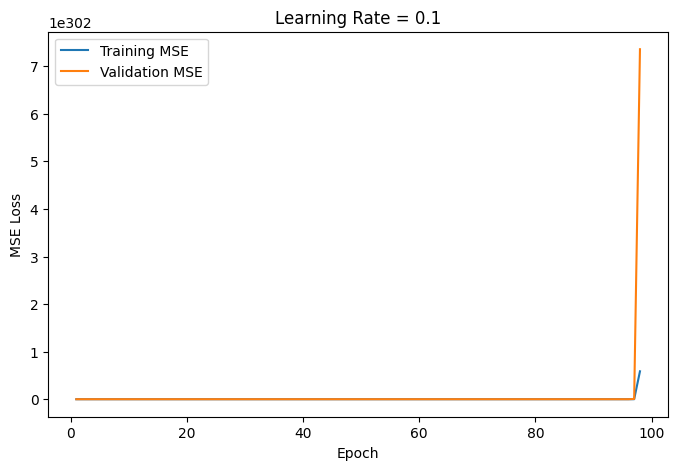

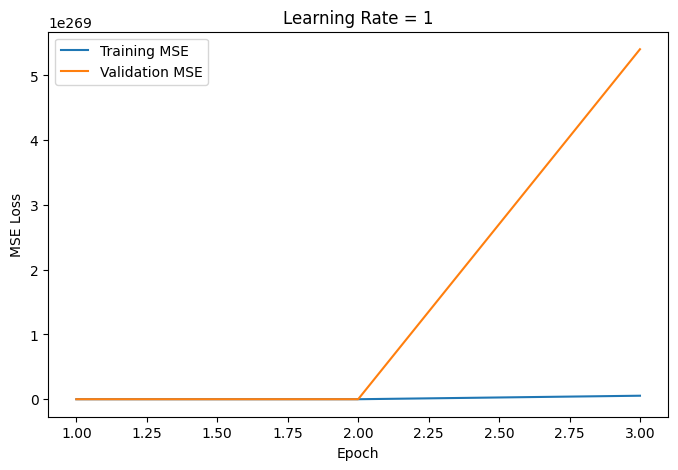

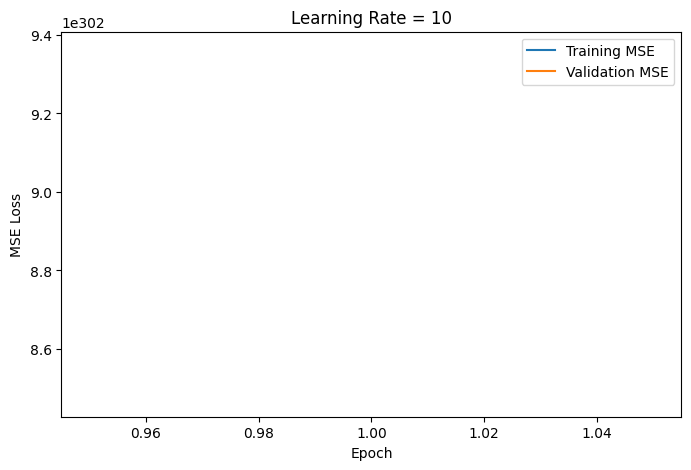

In [73]:
import matplotlib.pyplot as plt

for lr in learning_rates:
    train_losses = results_lr[lr]["train_losses"]
    val_losses = results_lr[lr]["val_losses"]

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize = (8, 5))

    plt.plot(epochs, train_losses, label ="Training MSE")
    plt.plot(epochs, val_losses, label = "Validation MSE")

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Learning Rate = {lr}")
    plt.legend()

    plt.show()

In [74]:
best_lr = None
best_val_mse = np.inf
best_epoch = None

for lr in learning_rates:
    val_losses = np.array(results_lr[lr]["val_losses"])
    finite_losses_only = val_losses[np.isfinite(val_losses)]

    if len(finite_losses_only) > 0:
        min_val_mse = np.min(val_losses)
        min_epoch = np.argmin(val_losses) + 1

        if min_val_mse < best_val_mse:
            best_val_mse = min_val_mse
            best_epoch = min_epoch
            best_lr = lr

print(f"Best Learning Rate is {best_lr}")
print(f"Best LR comes in epoch {best_epoch}")
print(f"Lowest Validation MSE is {best_val_mse}")

Best Learning Rate is 0.01
Best LR comes in epoch 26
Lowest Validation MSE is 0.3904515945896926


<h3>Task #4</h3>
<h4>
Using the best learning rate obtained in Task 3, investigate the effect of batch size on the performance and optimization behavior of Gradient Descent.

Experiment with the following batch sizes:
[ 1, 16, 32, 64, 128, 256, Entire Training Dataset ]

• Keep all other settings unchanged across the experiments, only the batch size should
be changed between experiments.

• Summarize the results in a table containing the batch size, lowest validation MSE achieved and its corresponding epoch number at which it was achieved. Note that the number of epochs is not a direct measure of computational efficiency, since different batch sizes perform different numbers of parameter updates per epoch.

• Plot the train and validation loss curves for the 7 batch sizes (7 plots) to understand the behaviour and smoothness of the training and validation MSE curves. Select the batch size that gives the best validation performance.
</h4>

In [77]:
batch_sizes = [1, 16, 32, 64, 128, 256, len(X_train)]

results_batch = {}

for batch_size in batch_sizes:
    best_W, best_epoch, best_val_mse, train_losses, val_losses = train_model(
        X_train,
        Y_train,
        X_val,
        Y_val, 
        learning_rate = best_lr,
        batch_size = batch_size
    )

    results_batch[batch_size] = {
        "W": best_W,
        "best_epoch": best_epoch,
        "best_val_mse": best_val_mse,
        "train_losses": train_losses,
        "val_losses": val_losses   
    }

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27304\3693895233.py:7: RuntimeWarning: overflow encountered in square
  return np.mean(error ** 2)


In [78]:
import pandas as pd

batch_results_table = []

for batch_size in batch_sizes:
    batch_results_table.append(
        [
            batch_size,
            results_batch[batch_size]["best_val_mse"],
            results_batch[batch_size]["best_epoch"]
        ]
    )

batch_results_table = pd.DataFrame(
    batch_results_table,
    columns = ["Batch Size", "Lowest Validation MSE", "Best Epoch"]
)

batch_results_table

,Batch Size,Lowest Validation MSE,Best Epoch
0,1,2.935399e+08,1
1,16,3.512336e+01,1
2,32,6.208648e-01,1
3,64,3.904677e-01,95
4,128,3.905331e-01,107
5,256,3.911683e-01,136
6,12384,3.963958e-01,1000


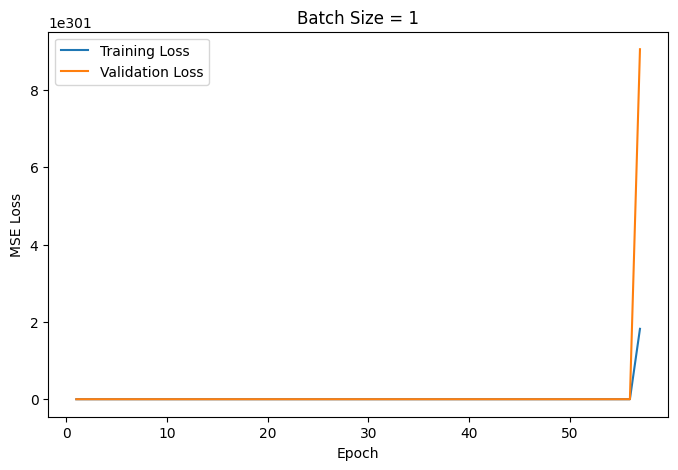

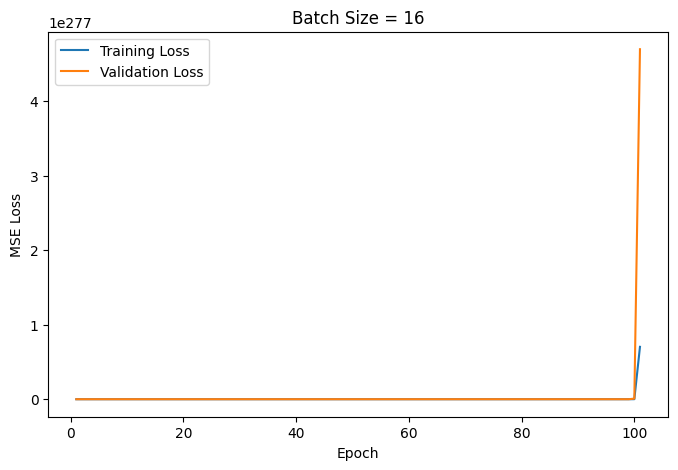

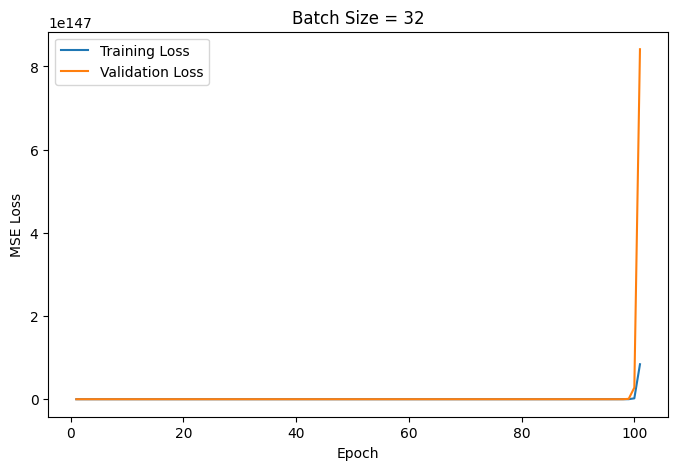

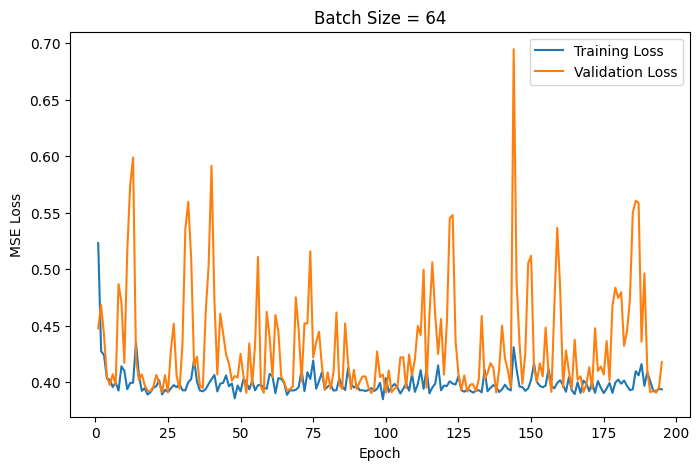

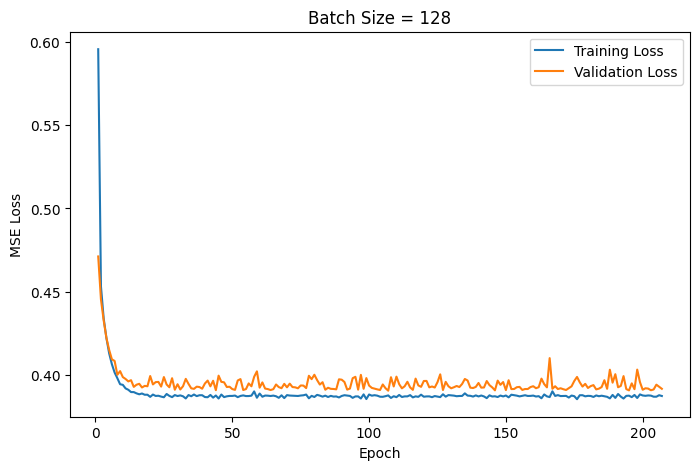

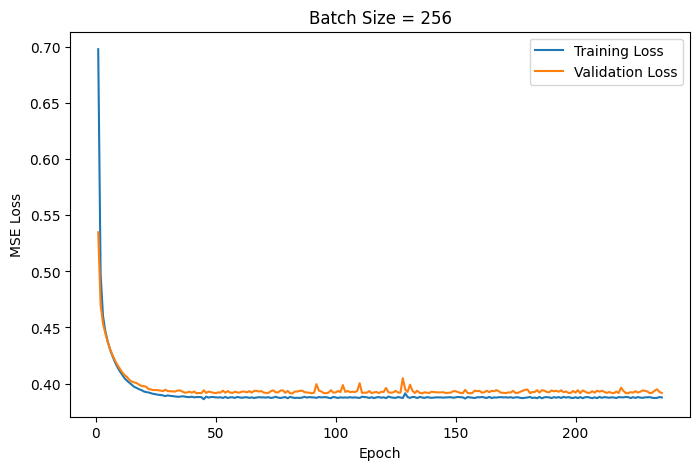

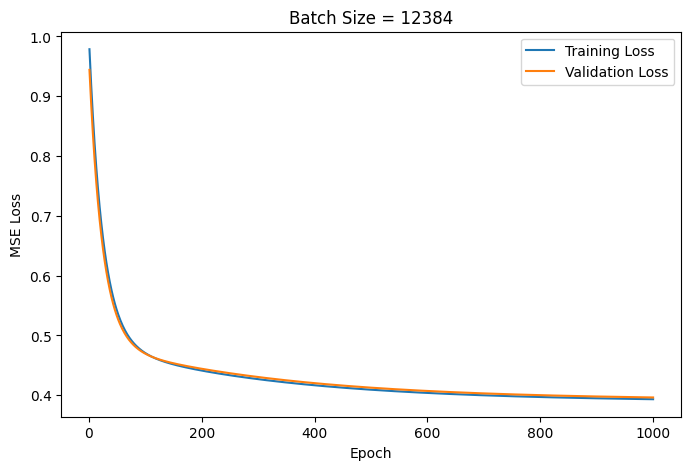

In [84]:
import matplotlib.pyplot as plt

for batch_size in batch_sizes:
    train_losses = results_batch[batch_size]["train_losses"]
    val_losses = results_batch[batch_size]["val_losses"]

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize = (8, 5))

    plt.plot(epochs, train_losses, label="Training Loss")
    plt.plot(epochs, val_losses, label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")

    plt.title(f"Batch Size = {batch_size}")
    plt.legend()

    plt.show()

In [85]:
best_batch_size = None
best_batch_val_mse = np.inf
best_batch_epoch = None

for batch_size in batch_sizes:
    val_mse = results_batch[batch_size]["best_val_mse"]
    epoch = results_batch[batch_size]["best_epoch"]

    if val_mse < best_batch_val_mse:
        best_batch_val_mse = val_mse
        best_batch_size = batch_size
        best_batch_epoch = epoch

print(f"Best batch size is {best_batch_size}")
print(f"Lowest validation MSE is {best_batch_val_mse}")
print(f"Best epoch is {best_batch_epoch}")

Best batch size is 64
Lowest validation MSE is 0.39046769935892417
Best epoch is 95


<h3>Task #5</h3>
<h4>
Using the best model obtained with best learning rate and batch size from the previous tasks:
    
1. Evaluate the model with the best validation performance on the unseen test set.
2. Report the following metrics for the Test set: RMSE, MAPE, MAE, R-squared in a
Table for the training, validation and test set to compare their performance.
3. Plot Actual vs Predicted values using a scatter plot.
</h4>

In [87]:
best_W = results_batch[best_batch_size]["W"]

print("Best learning rate:", best_lr)
print("Best batch size:", best_batch_size)

Y_train_pred = predict(X_train, best_W)
Y_val_pred = predict(X_val, best_W)
Y_test_pred = predict(X_test, best_W)

Y_train_pred = Y_train_pred * Y_std + Y_mean
Y_val_pred = Y_val_pred * Y_std + Y_mean
Y_test_pred = Y_test_pred * Y_std + Y_mean

Best learning rate: 0.01
Best batch size: 64


In [88]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    return 1 - (ss_res/ss_tot)

train_rmse = rmse(Y_train_original, Y_train_pred)
train_mape = mape(Y_train_original, Y_train_pred)
train_mae = mae(Y_train_original, Y_train_pred)
train_r2 = r_squared(Y_train_original, Y_train_pred)

val_rmse = rmse(Y_val_original, Y_val_pred)
val_mape = mape(Y_val_original, Y_val_pred)
val_mae = mae(Y_val_original, Y_val_pred)
val_r2 = r_squared(Y_val_original, Y_val_pred)

test_rmse = rmse(Y_test_original, Y_test_pred)
test_mape = mape(Y_test_original, Y_test_pred)
test_mae = mae(Y_test_original, Y_test_pred)
test_r2 = r_squared(Y_test_original, Y_test_pred)

In [91]:
metrics_table = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],
    "MAE": [train_mae, val_mae, test_mae],
    "RMSE": [train_rmse, val_rmse, test_rmse],
    "MAPE": [train_mape, val_mape, test_mape],
    "R2": [train_r2, val_r2, test_r2]
})

metrics_table

,Dataset,MAE,RMSE,MAPE,R2
0,Training,0.528866,0.722730,31.684765,0.610081
1,Validation,0.534164,0.723238,31.545297,0.595138
2,Test,0.532660,0.730199,31.386618,0.603792


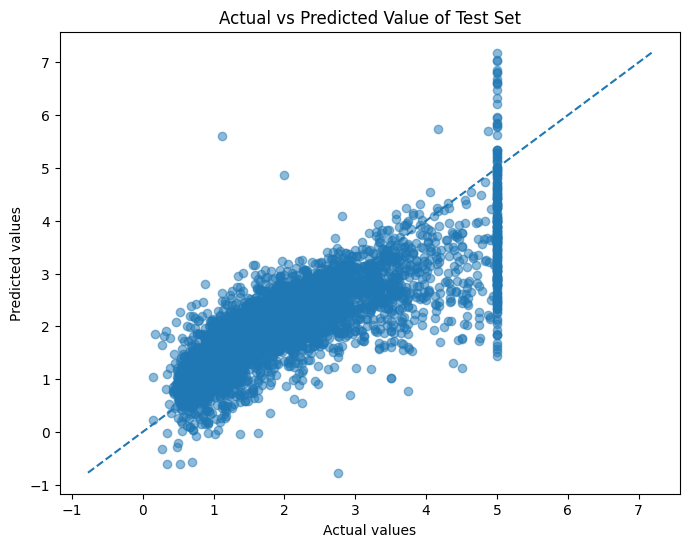

In [92]:
plt.figure(figsize = (8, 6))
plt.scatter(Y_test_original, Y_test_pred, alpha=0.5)

min_value = min(Y_test_original.min(), Y_test_pred.min())
max_value = max(Y_test_original.max(), Y_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted Value of Test Set")

plt.show()